In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data # type: ignore
y = iris.target # type: ignore
X.shape, y.shape

((150, 4), (150,))

In [6]:
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_compressed = pca.fit_transform(X)
X_compressed[:5]

array([[-2.68412563,  0.31939725, -0.02791483],
       [-2.71414169, -0.17700123, -0.21046427],
       [-2.88899057, -0.14494943,  0.01790026],
       [-2.74534286, -0.31829898,  0.03155937],
       [-2.72871654,  0.32675451,  0.09007924]])

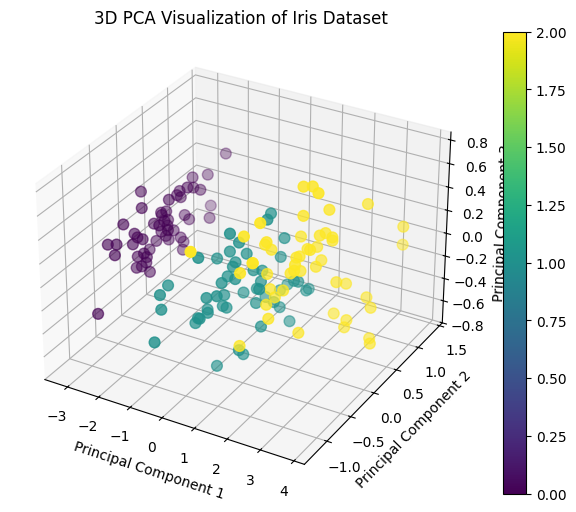

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Example: X_compressed should be your PCA output (150 x 3)
# target contains iris class labels (0,1,2)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter3D(
    X_compressed[:,0],
    X_compressed[:,1],
    X_compressed[:,2], # type: ignore
    c=y,
    cmap='viridis',
    s=60
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Visualization of Iris Dataset")

plt.colorbar(scatter)
plt.show()

In [13]:
pca1, pca2 = PCA(n_components=1), PCA(n_components=2)
X_comp1, X_comp2 = pca1.fit_transform(X), pca2.fit_transform(X)


In [14]:
X_comp1.shape, X_comp2.shape, X_compressed.shape

((150, 1), (150, 2), (150, 3))

C:\Users\bisha\AppData\Local\Temp\ipykernel_5484\1145605874.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


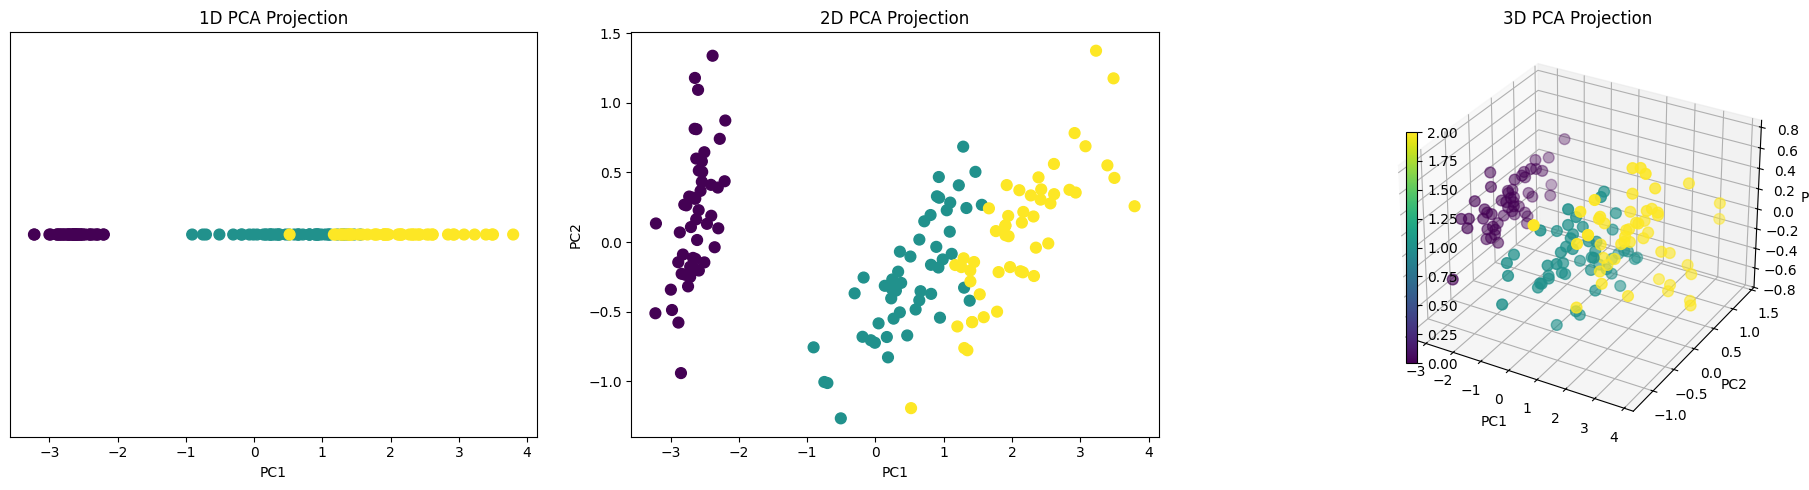

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(18,5))

# ---- 1D PCA ----
ax1 = fig.add_subplot(1,3,1)

ax1.scatter(X_comp1[:,0], [0]*len(X_comp1), c=y, cmap='viridis', s=60)
ax1.set_title("1D PCA Projection")
ax1.set_xlabel("PC1")
ax1.set_yticks([])


# ---- 2D PCA ----
ax2 = fig.add_subplot(1,3,2)

ax2.scatter(X_comp2[:,0], X_comp2[:,1], c=y, cmap='viridis', s=60)
ax2.set_title("2D PCA Projection")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")


# ---- 3D PCA ----
ax3 = fig.add_subplot(1,3,3, projection='3d')

scatter = ax3.scatter(
    X_compressed[:,0],
    X_compressed[:,1],
    X_compressed[:,2], # type: ignore
    c=y,
    cmap='viridis',
    s=60
)

ax3.set_title("3D PCA Projection")
ax3.set_xlabel("PC1")
ax3.set_ylabel("PC2")
ax3.set_zlabel("PC3")

fig.colorbar(scatter, ax=[ax1, ax2, ax3], shrink=0.6)

plt.tight_layout()
plt.show()